## Logistic Regression

In [11]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

from src.evaluation import *
from src.visualization import plot_metric_surface

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
x_train = pd.read_csv("../data/x_train.txt", sep=" ")
y_train = pd.read_csv("../data/y_train.txt")

scaler = MinMaxScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

y_train = y_train.squeeze()

In [13]:
feature_importance_df = pd.read_csv("../outputs/feature_importance_ranking.csv")

In [ ]:
C_VALUES = [5, 10, 20]
K_VALUES = range(1, 21)
TOP_N_VALUES = [50, 100, 250, 500, 1000]

sorted_features = feature_importance_df.sort_values("l1_rank")["feature"].values

all_results = []

for C in C_VALUES:
    print(f"Running: C={C}")

    for k in K_VALUES:
        
        for t in TOP_N_VALUES:

            selected_features = sorted_features[:k]
            X_sel = x_train_scaled[selected_features]

            model = LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=10_000,
            )

            summary = cross_val_eval(
                model=model, X=X_sel, y=y_train, 
                n_features=k, model_name=f"logreg_C={C}_k={k}",
                top_n=t)

            summary["C"] = C

            all_results.append(summary)

final_results = pd.DataFrame(all_results)

Running: C=5
Running: C=10
Running: C=20
Running: C=100


In [17]:
final_results.sort_values(by="score", ascending=False).head(10)

,accuracy,precision,recall,f1,profit,score,n_features,accuracy_std,precision_std,recall_std,f1_std,profit_std,score_std,model,threshold,top_n,C
204,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=20_k=1,None,1000,20
4,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=5_k=1,None,1000,5
104,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=10_k=1,None,1000,10
304,0.4976,0.4976,1.0,0.66453,2464.0,2264.0,1,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=100_k=1,None,1000,100
209,0.4976,0.4976,1.0,0.66453,2464.0,2064.0,2,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=20_k=2,None,1000,20
9,0.4976,0.4976,1.0,0.66453,2464.0,2064.0,2,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=5_k=2,None,1000,5
109,0.4976,0.4976,1.0,0.66453,2464.0,2064.0,2,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=10_k=2,None,1000,10
309,0.4976,0.4976,1.0,0.66453,2464.0,2064.0,2,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=100_k=2,None,1000,100
114,0.4976,0.4976,1.0,0.66453,2464.0,1864.0,3,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=10_k=3,None,1000,10
14,0.4976,0.4976,1.0,0.66453,2464.0,1864.0,3,0.000548,0.000548,0.0,0.000488,8.215838,8.215838,logreg_C=5_k=3,None,1000,5


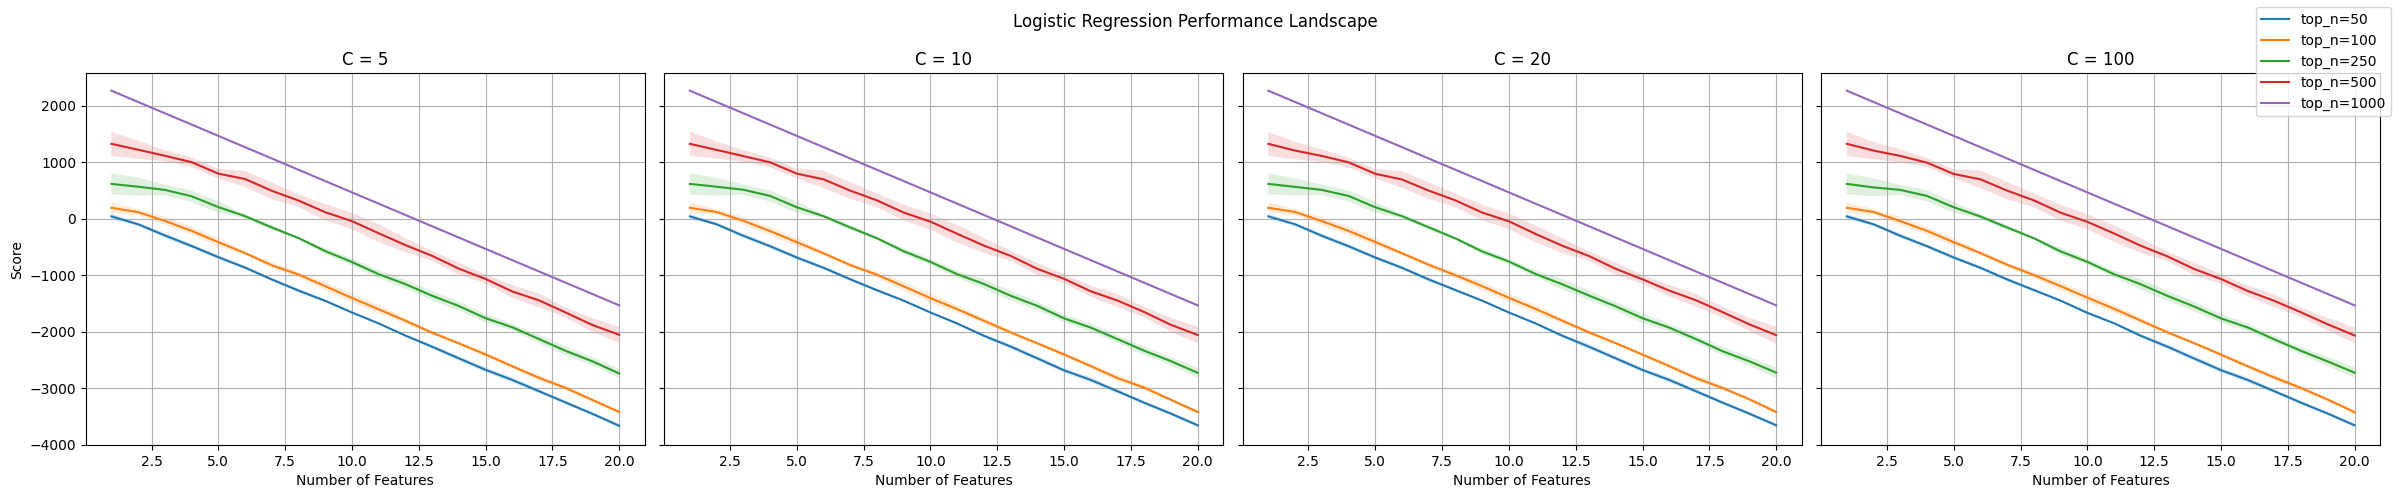

In [20]:
plot_metric_surface(
    df=final_results,
    x_col="n_features",
    y_col="score",
    split_col="C",
    line_col="top_n",
    std_col="score_std",
    title="Logistic Regression Performance Landscape",
    x_label="Number of Features",
    y_label="Score"
)